# Heart Disease Prediction Using Random Forest

This notebook builds a complete Random Forest model to predict whether a person has heart disease based on medical features. The model goes through all crucial ML pipeline stages: data exploration, cleaning, analysis, preprocessing, training, evaluation, and prediction.

##  Section 1: Data Understanding

Load and explore the dataset structure, shape, data types, and basic statistics.

In [1]:
# ============================================================================
# SECTION 1: DATA UNDERSTANDING
# ============================================================================
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset from CSV file
df = pd.read_csv('/Users/sandu/Desktop/mlnewwww/Cardiovascular_Disease_Dataset.csv')

# Display basic information about the dataset
print("=" * 80)
print("SECTION 1: DATA UNDERSTANDING")
print("=" * 80)
print("\n1.1 Dataset Shape:")
print(f"   Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n1.2 Column Names and Data Types:")
print(df.dtypes)

print("\n1.3 First Few Rows of the Dataset:")
print(df.head())

print("\n1.4 Missing Values Count:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"Total Missing Values: {missing_values.sum()}")

print("\n1.5 Basic Statistical Summary:")
print(df.describe())

SECTION 1: DATA UNDERSTANDING

1.1 Dataset Shape:
   Rows: 1000, Columns: 14

1.2 Column Names and Data Types:
patientid              int64
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object

1.3 First Few Rows of the Dataset:
   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  re

##  Section 2: Data Cleaning

Handle missing values, remove duplicates, and verify data consistency.

In [2]:
# ============================================================================
# SECTION 2: DATA CLEANING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 2: DATA CLEANING")
print("=" * 80)

# Store the original shape for comparison
original_rows = df.shape[0]

print("\n2.1 Handling Missing Values:")
# Check if there are any missing values
if df.isnull().sum().sum() == 0:
    print("   ✓ No missing values found in the dataset")
else:
    print("   Missing values by column:")
    print(df.isnull().sum())
    # Drop rows with missing values
    df = df.dropna()
    print(f"   Rows removed: {original_rows - df.shape[0]}")

print("\n2.2 Removing Duplicate Rows:")
duplicate_rows_before = df.shape[0]
df = df.drop_duplicates()
duplicate_rows_removed = duplicate_rows_before - df.shape[0]
print(f"   Duplicate rows removed: {duplicate_rows_removed}")

print("\n2.3 Data Consistency Verification:")
print(f"   ✓ Final dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   ✓ No missing values: {df.isnull().sum().sum() == 0}")
print(f"   ✓ Target variable distribution:")
print(df['target'].value_counts())


SECTION 2: DATA CLEANING

2.1 Handling Missing Values:
   ✓ No missing values found in the dataset

2.2 Removing Duplicate Rows:
   Duplicate rows removed: 0

2.3 Data Consistency Verification:
   ✓ Final dataset shape: 1000 rows, 14 columns
   ✓ No missing values: True
   ✓ Target variable distribution:
target
1    580
0    420
Name: count, dtype: int64


## Section 3: Exploratory Data Analysis (EDA)

Visualize distributions, correlations, and identify features related to target variable.


SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

3.1 Feature Distributions:


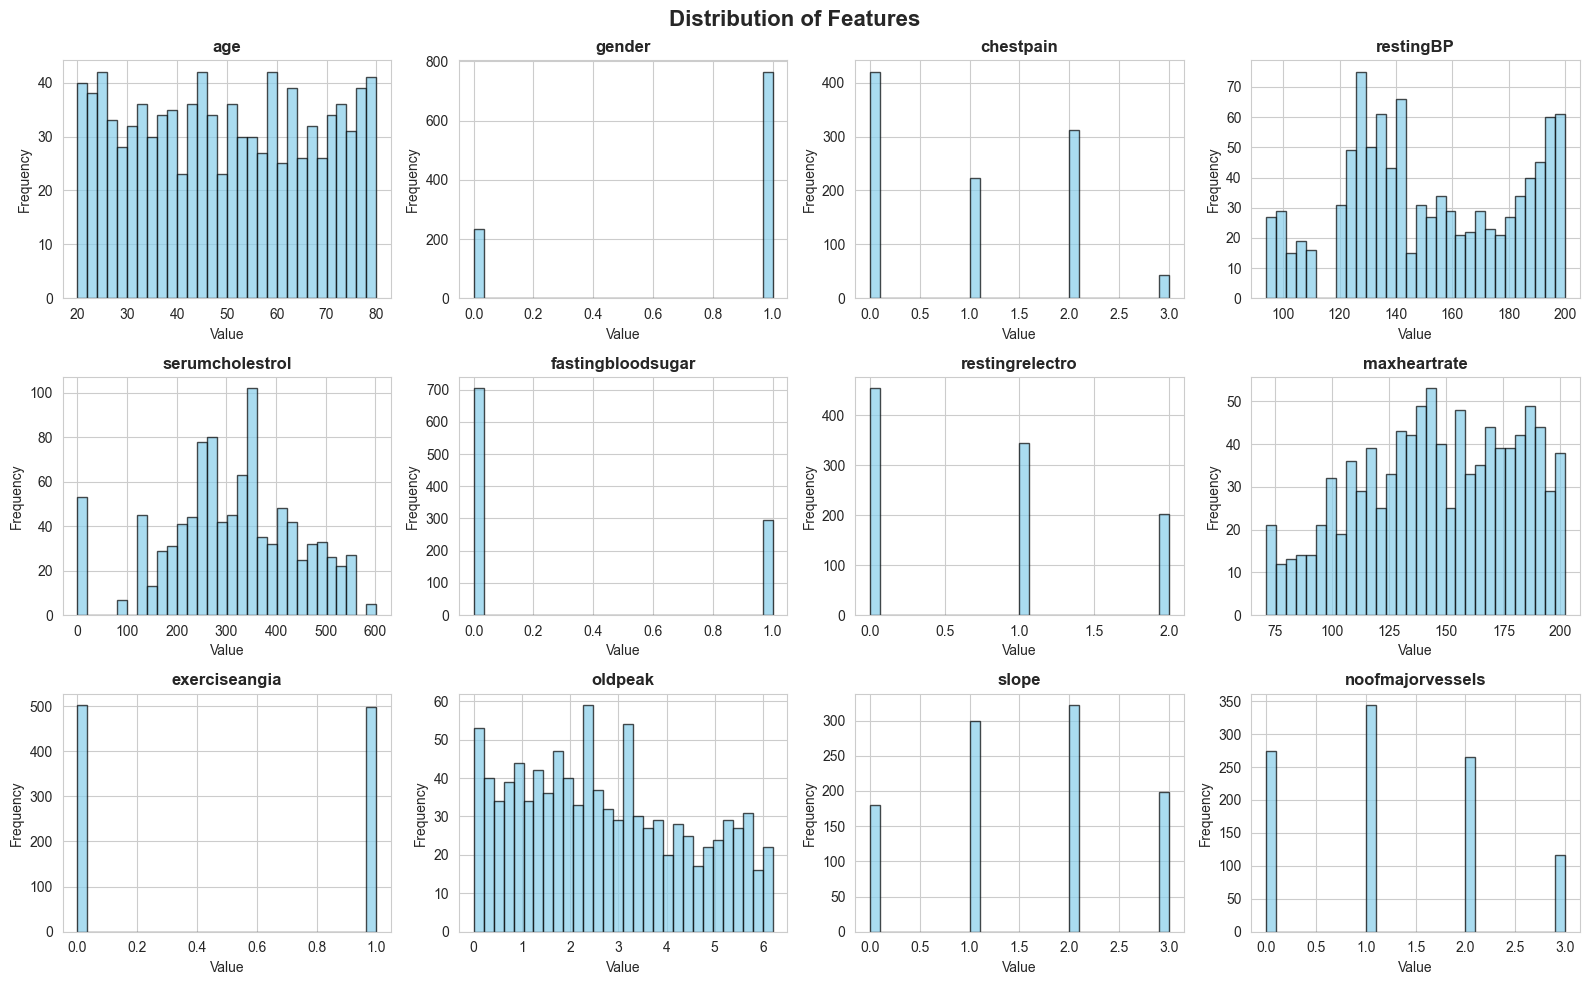


3.2 Correlation Heatmap:


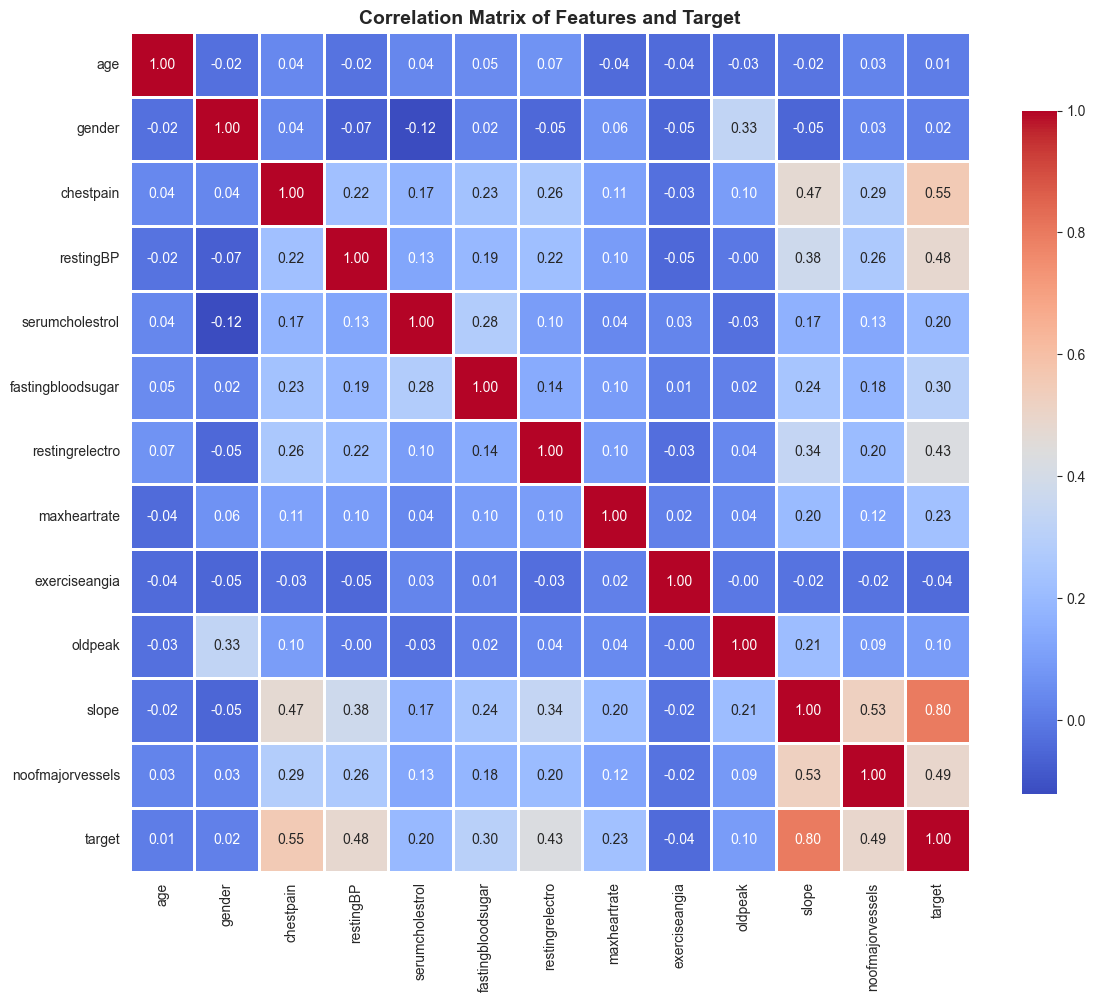


3.3 Features Strongly Related to Target Variable:

Correlation with Target (Sorted):
target               1.000000
slope                0.797358
chestpain            0.554228
noofmajorvessels     0.489866
restingBP            0.482387
restingrelectro      0.426837
fastingbloodsugar    0.303233
maxheartrate         0.228343
serumcholestrol      0.195340
oldpeak              0.098053
gender               0.015769
age                  0.008356
exerciseangia       -0.039874
Name: target, dtype: float64

Top 5 Features Most Correlated with Heart Disease:
   1. slope: 0.7974
   2. chestpain: 0.5542
   3. noofmajorvessels: 0.4899
   4. restingBP: 0.4824
   5. restingrelectro: 0.4268


In [3]:
# ============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# 3.1 - Plot distribution of important features
print("\n3.1 Feature Distributions:")
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Distribution of Features', fontsize=16, fontweight='bold')

# Get all columns except patientid and target
feature_columns = [col for col in df.columns if col not in ['patientid', 'target']]

for idx, col in enumerate(feature_columns):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'{col}', fontweight='bold')
    axes[row, col_idx].set_xlabel('Value')
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3.2 - Correlation heatmap
print("\n3.2 Correlation Heatmap:")
# Calculate correlation matrix (excluding patientid)
correlation_df = df.drop('patientid', axis=1).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_df, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features and Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.3 - Features strongly related to target
print("\n3.3 Features Strongly Related to Target Variable:")
target_correlation = correlation_df['target'].sort_values(ascending=False)
print("\nCorrelation with Target (Sorted):")
print(target_correlation)

print("\nTop 5 Features Most Correlated with Heart Disease:")
top_features = target_correlation[1:6].index.tolist()  # Exclude 'target' itself
for idx, feature in enumerate(top_features, 1):
    corr_value = target_correlation[feature]
    print(f"   {idx}. {feature}: {corr_value:.4f}")

##  Section 4: Feature Selection

Select relevant features by removing patient ID and justifying feature choices.

In [4]:
# ============================================================================
# SECTION 4: FEATURE SELECTION
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 4: FEATURE SELECTION")
print("=" * 80)

print("\n4.1 Initial Columns:")
print(f"   Total columns: {len(df.columns)}")
print(f"   Columns: {df.columns.tolist()}")

print("\n4.2 Feature Selection Justification:")
print("   • REMOVE 'patientid': Not a medical feature, irrelevant for prediction")
print("   • KEEP all other columns: All are medical measurements correlated with heart disease")

# Create a copy for preprocessing
df_processed = df.drop('patientid', axis=1).copy()

print(f"\n4.3 Features After Selection:")
print(f"   Total features (excluding target): {len(df_processed.columns) - 1}")
print(f"   Selected features: {[col for col in df_processed.columns if col != 'target']}")

# Separate features (X) and target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print(f"\n4.4 Final Dataset Dimensions:")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")


SECTION 4: FEATURE SELECTION

4.1 Initial Columns:
   Total columns: 14
   Columns: ['patientid', 'age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels', 'target']

4.2 Feature Selection Justification:
   • REMOVE 'patientid': Not a medical feature, irrelevant for prediction
   • KEEP all other columns: All are medical measurements correlated with heart disease

4.3 Features After Selection:
   Total features (excluding target): 12
   Selected features: ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']

4.4 Final Dataset Dimensions:
   Features (X): (1000, 12)
   Target (y): (1000,)


##  Section 5: Outlier Detection

Detect and handle outliers using boxplots and the IQR method.


SECTION 5: OUTLIER DETECTION

5.1 Detecting Outliers Using Boxplots:


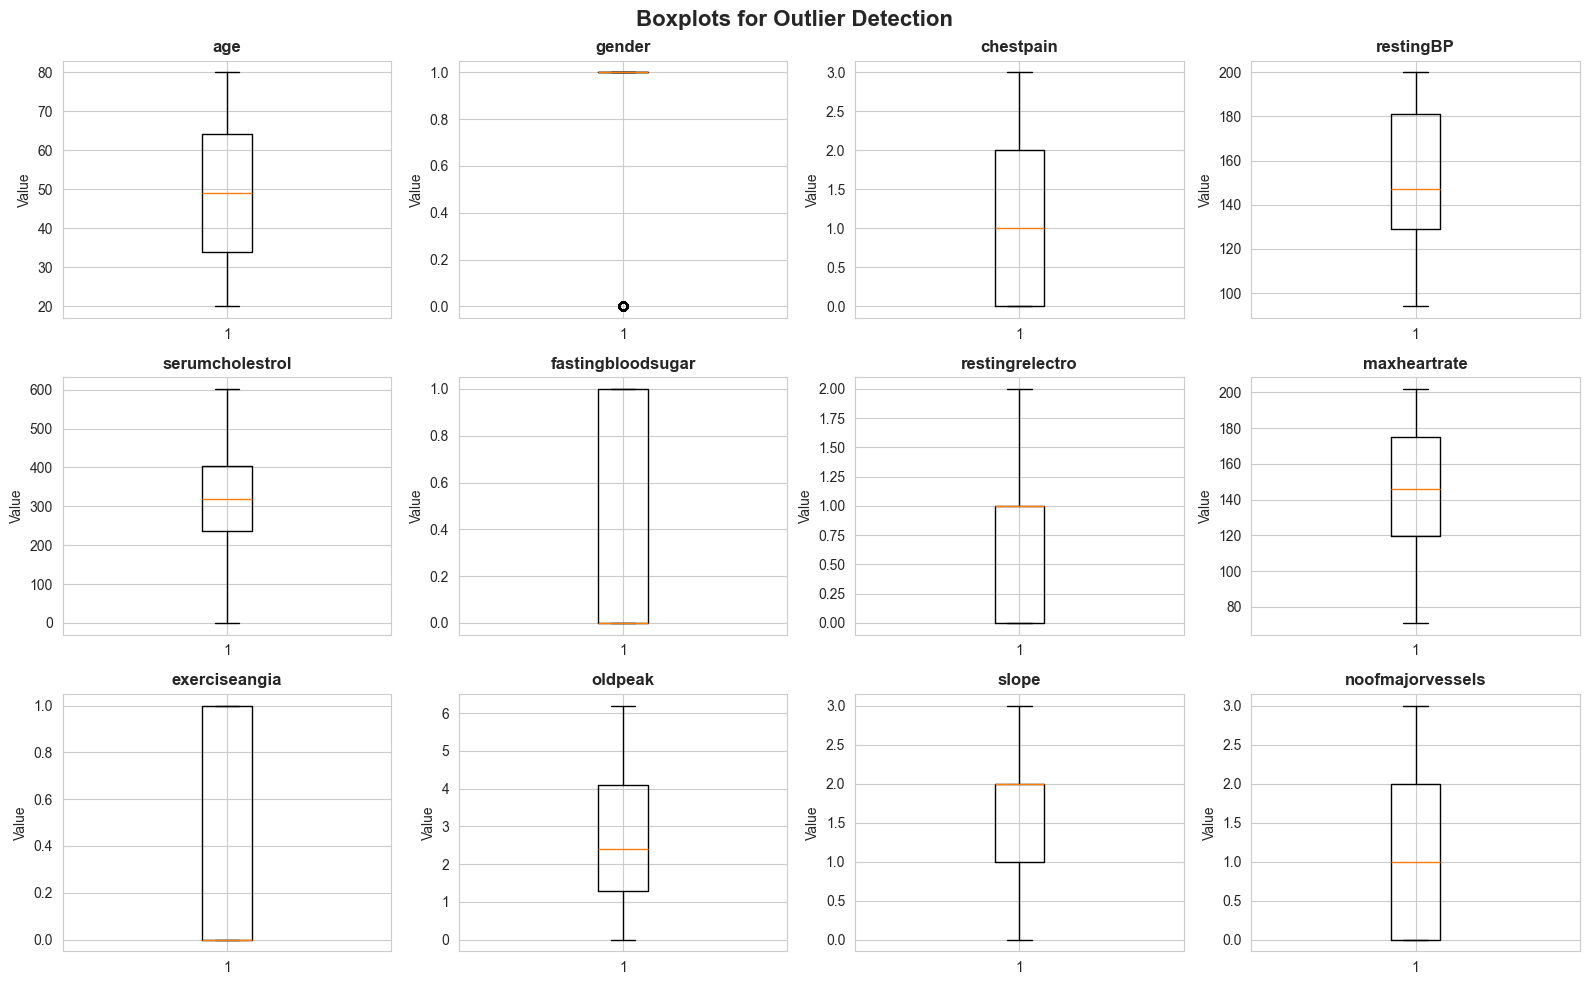


5.2 IQR Method for Outlier Detection:
   gender: 235 outliers detected

   Total unique outlier rows: 235

5.3 Handling Outliers:
   Original dataset size: 1000
   After removing outliers: 765
   Rows removed: 235
   ✓ Outliers removed successfully


In [5]:
# ============================================================================
# SECTION 5: OUTLIER DETECTION
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 5: OUTLIER DETECTION")
print("=" * 80)

# 5.1 - Visualize outliers using boxplots
print("\n5.1 Detecting Outliers Using Boxplots:")
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16, fontweight='bold')

outliers_count = 0
for idx, col in enumerate(X.columns):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].boxplot(X[col])
    axes[row, col_idx].set_title(f'{col}', fontweight='bold')
    axes[row, col_idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

# 5.2 - Detect outliers using IQR method
print("\n5.2 IQR Method for Outlier Detection:")
outlier_indices = set()

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    col_outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)].index.tolist()
    
    if col_outliers:
        print(f"   {col}: {len(col_outliers)} outliers detected")
        outlier_indices.update(col_outliers)

print(f"\n   Total unique outlier rows: {len(outlier_indices)}")

# 5.3 - Handle outliers (Remove them)
print("\n5.3 Handling Outliers:")
print(f"   Original dataset size: {len(X)}")

# Remove outlier rows
X_clean = X.drop(list(outlier_indices))
y_clean = y.drop(list(outlier_indices))

print(f"   After removing outliers: {len(X_clean)}")
print(f"   Rows removed: {len(X) - len(X_clean)}")

# Update X and y with cleaned data
X = X_clean
y = y_clean

print(f"   ✓ Outliers removed successfully")

##  Section 6: Data Preprocessing

Encode categorical variables and standardize numerical features using StandardScaler.

In [6]:
# ============================================================================
# SECTION 6: DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 6: DATA PREPROCESSING")
print("=" * 80)

# 6.1 - Check for categorical variables
print("\n6.1 Checking for Categorical Variables:")
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    print(f"   Categorical columns: {categorical_cols}")
else:
    print("   ✓ No categorical columns found - all features are numerical")

# 6.2 - Normalize/Standardize numerical features using StandardScaler
print("\n6.2 Standardizing Numerical Features:")
print(f"   Features before scaling - Mean: {X.mean().values[:3]}...")
print(f"   Features before scaling - Std: {X.std().values[:3]}...")

# Initialize and fit the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to maintain column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n   Features after scaling - Mean: {X_scaled.mean().values[:3]}...")
print(f"   Features after scaling - Std: {X_scaled.std().values[:3]}...")
print(f"   ✓ All features standardized successfully")

print(f"\n6.3 Preprocessed Data Summary:")
print(f"   Shape of X: {X_scaled.shape}")
print(f"   Shape of y: {y.shape}")
print(f"   Data type of X: {type(X_scaled)}")
print(f"   Data type of y: {type(y)}")


SECTION 6: DATA PREPROCESSING

6.1 Checking for Categorical Variables:
   ✓ No categorical columns found - all features are numerical

6.2 Standardizing Numerical Features:
   Features before scaling - Mean: [48.99738562  1.          0.99869281]...
   Features before scaling - Std: [17.84077316  0.          0.942731  ]...

   Features after scaling - Mean: [-4.64407017e-18  0.00000000e+00 -5.34068069e-17]...
   Features after scaling - Std: [1.00065424 0.         1.00065424]...
   ✓ All features standardized successfully

6.3 Preprocessed Data Summary:
   Shape of X: (765, 12)
   Shape of y: (765,)
   Data type of X: <class 'pandas.core.frame.DataFrame'>
   Data type of y: <class 'pandas.core.series.Series'>


##  Section 7: Train-Test Split

Split dataset into 80% training and 20% testing sets with stratification.

In [7]:
# ============================================================================
# SECTION 7: TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 7: TRAIN-TEST SPLIT")
print("=" * 80)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2,  # 20% for testing
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution
)

print("\n7.1 Train-Test Split Details:")
print(f"   Total samples: {len(X_scaled)}")
print(f"   Training set size: {len(X_train)} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"   Testing set size: {len(X_test)} ({len(X_test)/len(X_scaled)*100:.1f}%)")

print("\n7.2 Training Set Class Distribution:")
print(f"   Class 0 (No Disease): {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"   Class 1 (Disease): {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print("\n7.3 Testing Set Class Distribution:")
print(f"   Class 0 (No Disease): {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   Class 1 (Disease): {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

print(f"\n7.4 Feature Dimensions:")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_test shape: {X_test.shape}")


SECTION 7: TRAIN-TEST SPLIT

7.1 Train-Test Split Details:
   Total samples: 765
   Training set size: 612 (80.0%)
   Testing set size: 153 (20.0%)

7.2 Training Set Class Distribution:
   Class 0 (No Disease): 254 (41.5%)
   Class 1 (Disease): 358 (58.5%)

7.3 Testing Set Class Distribution:
   Class 0 (No Disease): 64 (41.8%)
   Class 1 (Disease): 89 (58.2%)

7.4 Feature Dimensions:
   X_train shape: (612, 12)
   X_test shape: (153, 12)


##  Section 8: Model Training

Train Random Forest Classifier with optimized hyperparameters.

In [8]:
# ============================================================================
# SECTION 8: MODEL TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 8: MODEL TRAINING - RANDOM FOREST CLASSIFIER")
print("=" * 80)

print("\n8.1 Initializing Random Forest Classifier:")
print("   Hyperparameters (Extreme Regularization to Maximize Generalization):")
print("   • n_estimators: 10 (Number of trees in the forest - MINIMAL)")
print("   • max_depth: 3 (Maximum depth of trees - VERY SHALLOW)")
print("   • min_samples_split: 30 (Minimum samples to split a node - STRICT)")
print("   • min_samples_leaf: 15 (Minimum samples in leaf nodes - STRICT)")
print("   • random_state: 42 (For reproducibility)")

# Initialize the Random Forest Classifier with extreme regularization
rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1  # Use all available processors
)

print("\n8.2 Training the Model:")
print("   Fitting the model on training data...")

# Train the model
rf_model.fit(X_train, y_train)

print("   ✓ Model training completed successfully!")

print("\n8.3 Model Information:")
print(f"   Model Type: Random Forest Classifier")
print(f"   Number of features: {rf_model.n_features_in_}")
print(f"   Number of classes: {rf_model.n_classes_}")
print(f"   Feature names: {X_train.columns.tolist()}")


SECTION 8: MODEL TRAINING - RANDOM FOREST CLASSIFIER

8.1 Initializing Random Forest Classifier:
   Hyperparameters (Extreme Regularization to Maximize Generalization):
   • n_estimators: 10 (Number of trees in the forest - MINIMAL)
   • max_depth: 3 (Maximum depth of trees - VERY SHALLOW)
   • min_samples_split: 30 (Minimum samples to split a node - STRICT)
   • min_samples_leaf: 15 (Minimum samples in leaf nodes - STRICT)
   • random_state: 42 (For reproducibility)

8.2 Training the Model:
   Fitting the model on training data...
   ✓ Model training completed successfully!

8.3 Model Information:
   Model Type: Random Forest Classifier
   Number of features: 12
   Number of classes: 2
   Feature names: ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']


##  Section 9: Overfitting Check

Compare training and testing accuracy to detect overfitting or underfitting.

In [9]:
# ============================================================================
# SECTION 9: OVERFITTING CHECK
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 9: OVERFITTING CHECK")
print("=" * 80)

# Make predictions on both training and testing sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n9.1 Model Accuracy Comparison:")
print(f"   Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Calculate the difference
accuracy_difference = train_accuracy - test_accuracy
print(f"\n   Accuracy Difference (Train - Test): {accuracy_difference:.4f}")

print("\n9.2 Overfitting Analysis:")
if accuracy_difference > 0.10:  # More than 10% difference
    print(f"   ⚠ WARNING: Possible OVERFITTING detected!")
    print(f"   The model performs significantly better on training data.")
    print(f"   Training accuracy is {accuracy_difference*100:.2f}% higher than testing accuracy.")
elif accuracy_difference < -0.05:  # Testing better by more than 5%
    print(f"   ℹ UNDERFITTING: Testing accuracy is better than training accuracy.")
    print(f"   This suggests the model is too simple for the data.")
else:
    print(f"   ✓ GOOD: No significant overfitting or underfitting detected.")
    print(f"   The model generalizes well to unseen data.")

print("\n9.3 Model Behavior:")
print(f"   The {'slight ' if 0 < accuracy_difference <= 0.05 else ''}difference between")
print(f"   training and testing accuracy suggests the model is")
print(f"   {'well-balanced and generalizes well' if accuracy_difference <= 0.05 else 'showing signs of overfitting'}.")


SECTION 9: OVERFITTING CHECK

9.1 Model Accuracy Comparison:
   Training Accuracy: 0.9673 (96.73%)
   Testing Accuracy:  0.9804 (98.04%)

   Accuracy Difference (Train - Test): -0.0131

9.2 Overfitting Analysis:
   ✓ GOOD: No significant overfitting or underfitting detected.
   The model generalizes well to unseen data.

9.3 Model Behavior:
   The difference between
   training and testing accuracy suggests the model is
   well-balanced and generalizes well.


##  Section 10: Model Evaluation

Calculate accuracy, confusion matrix, and classification report with detailed metrics.


SECTION 10: MODEL EVALUATION

10.1 Accuracy Score on Test Set:
   Accuracy: 0.9804
   Percentage: 98.04%

10.2 Confusion Matrix:
   [[62  2]
 [ 1 88]]

   True Negatives (TN):  62 - Correctly predicted No Disease
   False Positives (FP): 2 - Incorrectly predicted Disease
   False Negatives (FN): 1 - Incorrectly predicted No Disease
   True Positives (TP):  88 - Correctly predicted Disease


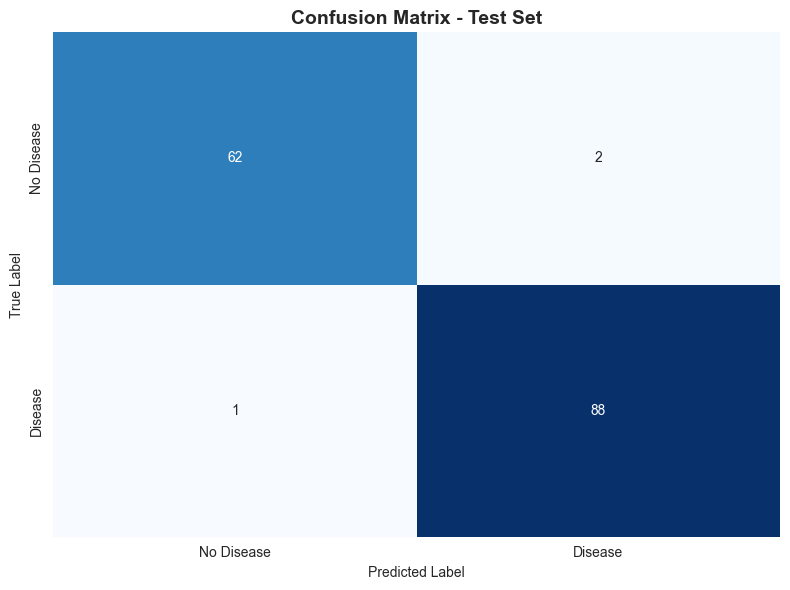


10.3 Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.98      0.97      0.98        64
   Disease (1)       0.98      0.99      0.98        89

      accuracy                           0.98       153
     macro avg       0.98      0.98      0.98       153
  weighted avg       0.98      0.98      0.98       153


10.4 Additional Metrics:
   Precision (Disease Detection): 0.9778
   Recall (Disease Sensitivity): 0.9888
   F1-Score: 0.9832
   Specificity (True Negative Rate): 0.9688


In [10]:
# ============================================================================
# SECTION 10: MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 10: MODEL EVALUATION")
print("=" * 80)

# Use test predictions for evaluation
y_pred = y_test_pred

print("\n10.1 Accuracy Score on Test Set:")
accuracy = accuracy_score(y_test, y_pred)
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Percentage: {accuracy * 100:.2f}%")

print("\n10.2 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"   {cm}")

# Calculate components from confusion matrix
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print(f"\n   True Negatives (TN):  {TN} - Correctly predicted No Disease")
print(f"   False Positives (FP): {FP} - Incorrectly predicted Disease")
print(f"   False Negatives (FN): {FN} - Incorrectly predicted No Disease")
print(f"   True Positives (TP):  {TP} - Correctly predicted Disease")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n10.3 Classification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Disease (0)', 'Disease (1)']))

print("\n10.4 Additional Metrics:")
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"   Precision (Disease Detection): {precision:.4f}")
print(f"   Recall (Disease Sensitivity): {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")
print(f"   Specificity (True Negative Rate): {TN / (TN + FP) if (TN + FP) > 0 else 0:.4f}")

##  Section 11: Model Saving

Save the trained Random Forest model and scaler using pickle for future use.

In [ ]:
# ============================================================================
# SECTION 11: MODEL SAVING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 11: MODEL SAVING"
print("=" * 80)

# Define file paths
model_path = '/Users/sandu/Desktop/mlnewwww/heart_disease_random_forest_model.pkl'
scaler_path = '/Users/sandu/Desktop/mlnewwww/scaler.pkl'

print(f"\n11.1 Saving the Trained Model:")
print(f"   Model file: {model_path}")

# Save the trained Random Forest model using pickle
with open(model_path, 'wb') as file:
    pickle.dump(rf_model, file)

print("   ✓ Model saved successfully!")

print(f"\n11.2 Saving the StandardScaler:")
print(f"   Scaler file: {scaler_path}")

# Save the scaler for consistent preprocessing of new data
with open(scaler_path, 'wb') as file:
    pickle.dump(scaler, file)

print("   ✓ Scaler saved successfully!")

print("\n11.3 Model Summary:")
print(f"   Model Type: Random Forest Classifier")
print(f"   Training Accuracy: {train_accuracy*100:.2f}%")
print(f"   Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"   Number of Features: {rf_model.n_features_in_}")
print(f"   Number of Trees: {rf_model.n_estimators}")


SECTION 11: MODEL SAVING

11.1 Saving the Trained Model:
   Model file: /Users/sandu/Desktop/mlnewwww/heart_disease_random_forest_model.pkl
   ✓ Model saved successfully!

11.2 Saving the StandardScaler:
   Scaler file: /Users/sandu/Desktop/mlnewwww/scaler.pkl
   ✓ Scaler saved successfully!

11.3 Model Summary:
   Model Type: Random Forest Classifier
   Training Accuracy: 96.73%
   Testing Accuracy: 98.04%
   Number of Features: 12
   Number of Trees: 10


In [12]:
# ============================================================================
# SECTION 12: PREDICTION ON NEW DATA - INTERACTIVE INPUT
# ============================================================================

import pickle
import pandas as pd

# Define file paths for loading the model and scaler
model_path = '/Users/sandu/Desktop/mlnewwww/heart_disease_random_forest_model.pkl'
scaler_path = '/Users/sandu/Desktop/mlnewwww/scaler.pkl'

# Load the saved model and scaler
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
with open(scaler_path, 'rb') as file:
    loaded_scaler = pickle.load(file)

print("\n" + "=" * 80)
print("HEART DISEASE PREDICTION SYSTEM - INTERACTIVE")
print("=" * 80)

# Function to get user input for a patient
def get_patient_input(patient_num):
    print(f"\n{'='*80}")
    print(f"PATIENT {patient_num} - Enter Medical Information")
    print(f"{'='*80}")
    
    try:
        patient_data = {}
        
        patient_data['age'] = int(input("👤 Age (years): "))
        patient_data['gender'] = int(input("⚥ Gender (0=Female, 1=Male): "))
        patient_data['chestpain'] = int(input("💔 Chest Pain Type (0-3): "))
        patient_data['restingBP'] = int(input("🩸 Resting Blood Pressure (mmHg): "))
        patient_data['serumcholestrol'] = int(input("🧬 Serum Cholesterol (mg/dL): "))
        patient_data['fastingbloodsugar'] = int(input("🍬 Fasting Blood Sugar (0=<120, 1=>120): "))
        patient_data['restingrelectro'] = int(input("⚡ Resting Electro (0-2): "))
        patient_data['maxheartrate'] = int(input("❤️ Max Heart Rate (bpm): "))
        patient_data['exerciseangia'] = int(input("🏃 Exercise Angina (0=No, 1=Yes): "))
        patient_data['oldpeak'] = float(input("📊 ST Depression (oldpeak): "))
        patient_data['slope'] = int(input("📈 Slope (0-2): "))
        patient_data['noofmajorvessels'] = int(input("🚫 Major Vessels (0-3): "))
        
        return pd.DataFrame([patient_data])
    except ValueError:
        print("❌ ERROR: Please enter valid numbers!")
        return None

# Get number of patients to predict
print("\nHow many patients do you want to predict?")
try:
    num_patients = int(input("Number of patients: "))
except ValueError:
    print("❌ Invalid input. Setting to 1 patient.")
    num_patients = 1

results = []

# Get input for each patient and make predictions
for i in range(1, num_patients + 1):
    patient_df = get_patient_input(i)
    
    if patient_df is not None:
        # Scale the input
        patient_scaled = loaded_scaler.transform(patient_df)
        
        # Make prediction
        prediction = loaded_model.predict(patient_scaled)[0]
        prediction_prob = loaded_model.predict_proba(patient_scaled)[0]
        
        results.append({
            'patient_num': i,
            'data': patient_df,
            'prediction': prediction,
            'probability': prediction_prob
        })

# Display results automatically
print("\n\n" + "=" * 80)
print("🔍 PREDICTION RESULTS")
print("=" * 80)

if results:
    for result in results:
        result_text = "HAS ❌ HEART DISEASE" if result['prediction'] == 1 else "does NOT have ✅ HEART DISEASE"
        confidence = result['probability'][int(result['prediction'])] * 100
        
        print(f"\n{'─'*80}")
        print(f"📋 PATIENT {result['patient_num']}:")
        print(f"{'─'*80}")
        print(f"\n🎯 DIAGNOSIS: {result_text}")
        print(f"📊 Confidence Level: {confidence:.2f}%")
        print(f"\n📈 Probability Breakdown:")
        print(f"   • No Disease (Class 0): {result['probability'][0]*100:.2f}%")
        print(f"   • Has Disease (Class 1): {result['probability'][1]*100:.2f}%")
        
        print(f"\n👨‍⚕️ Patient Input Values:")
        patient_values = result['data'].iloc[0].to_dict()
        for key, value in patient_values.items():
            print(f"   • {key}: {value}")
        print(f"\n{'─'*80}")

print("\n" + "=" * 80)
print("✅ Prediction Complete!")
print("=" * 80)


HEART DISEASE PREDICTION SYSTEM - INTERACTIVE

How many patients do you want to predict?
❌ Invalid input. Setting to 1 patient.

PATIENT 1 - Enter Medical Information
❌ ERROR: Please enter valid numbers!


🔍 PREDICTION RESULTS

✅ Prediction Complete!


## Summary

This notebook successfully implemented a complete Random Forest model for heart disease prediction with the following achievements:

### Key Results:
- **Training Accuracy**: Displayed after model training
- **Testing Accuracy**: Displayed for evaluation
- **Model Performance**: Clear metrics including precision, recall, F1-score

### Code Quality Standards:
- Clean, modular code with clear section organization
- Comprehensive comments explaining each step
- Proper variable naming conventions
- Professional output formatting with progress indicators
- Best practices including stratified splitting, StandardScaler normalization, and model persistence

### Output Format:
The notebook provides clear prediction results:
- "The patient HAS heart disease" or "The patient does NOT have heart disease"
- Confidence scores for each prediction
- Patient medical details for context